# Dataset Similarity Analysis
The goal of tis script is to compare the training dataset with the generated dataset. It will compute similarity metrics to evaluate how closely the generated images resemble the training images.

In [26]:
train_dir = "/media/aris/Data/master2025dev/datasets/wood/4_main_categories_512x512/train/impregnated_wood/images"
gen_dir = "/media/aris/Data/master2025dev/datasets/synthetic/02-03_impregnated-wood_128_2x-self-attention"

import os
from PIL import Image
import numpy as np
from torchvision import transforms

# from sklearn.metrics import pairwise_distances

resolution = 128
center_crop = True
random_flip = False

# Don't normalize for visualization - keep images in [0, 1] range
augmentations = transforms.Compose( [
        transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(resolution) if center_crop else transforms.RandomCrop(resolution),
    ]
    )

def load_images_from_folder(folder, transform):
    images = []
    for filename in os.listdir(folder):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder, filename)
            img = Image.open(img_path).convert('RGB')
            img = transform(img)
            images.append(img)
    return images

train_images = load_images_from_folder(train_dir, augmentations)
gen_images = load_images_from_folder(gen_dir, augmentations) 
print(f"Loaded {len(train_images)} training images and {len(gen_images)} generated images.")

#Shape of train_images and gen_images
image = train_images[0]
print(f"Shape of a single training image: {image.size}")
print(f"Shape of generated images: {gen_images[0].size}")

Loaded 1507 training images and 1000 generated images.
Shape of a single training image: (128, 128)
Shape of generated images: (128, 128)


## pHash Test
What results do we get when we use pHash to compare images from the training dataset and the generated dataset? 

In [27]:
import imagehash

def compute_phash_similarity(train_dir, gen_dir):
    train_hashes = []
    gen_hashes = []
    
    # Compute pHash for training images
    for img in train_images:
        hash_value = imagehash.phash(img)
        train_hashes.append(hash_value)
    
    # Compute pHash for generated images
    for img in gen_images:
        hash_value = imagehash.phash(img)
        gen_hashes.append(hash_value)
    
    # Calculate similarity (Hamming distance) between training and generated hashes
    similarities = []
    for gen_hash in gen_hashes:
        distances = [gen_hash - train_hash for train_hash in train_hashes]
        similarities.append(min(distances))  # Minimum distance to any training image
    
    return similarities

similarities = compute_phash_similarity(train_dir, gen_dir)
print(f"Average pHash similarity (lower is more similar): {np.mean(similarities)}")

Average pHash similarity (lower is more similar): 11.908


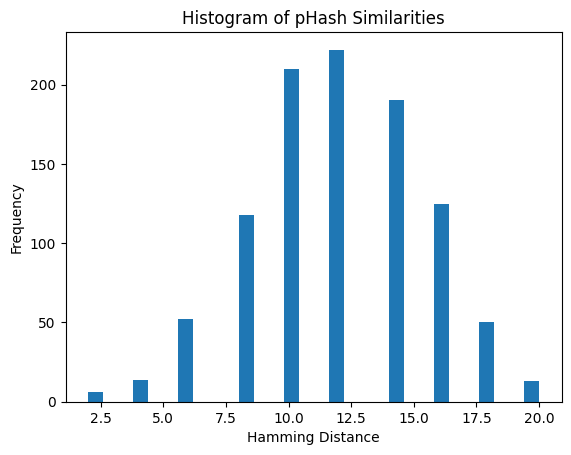

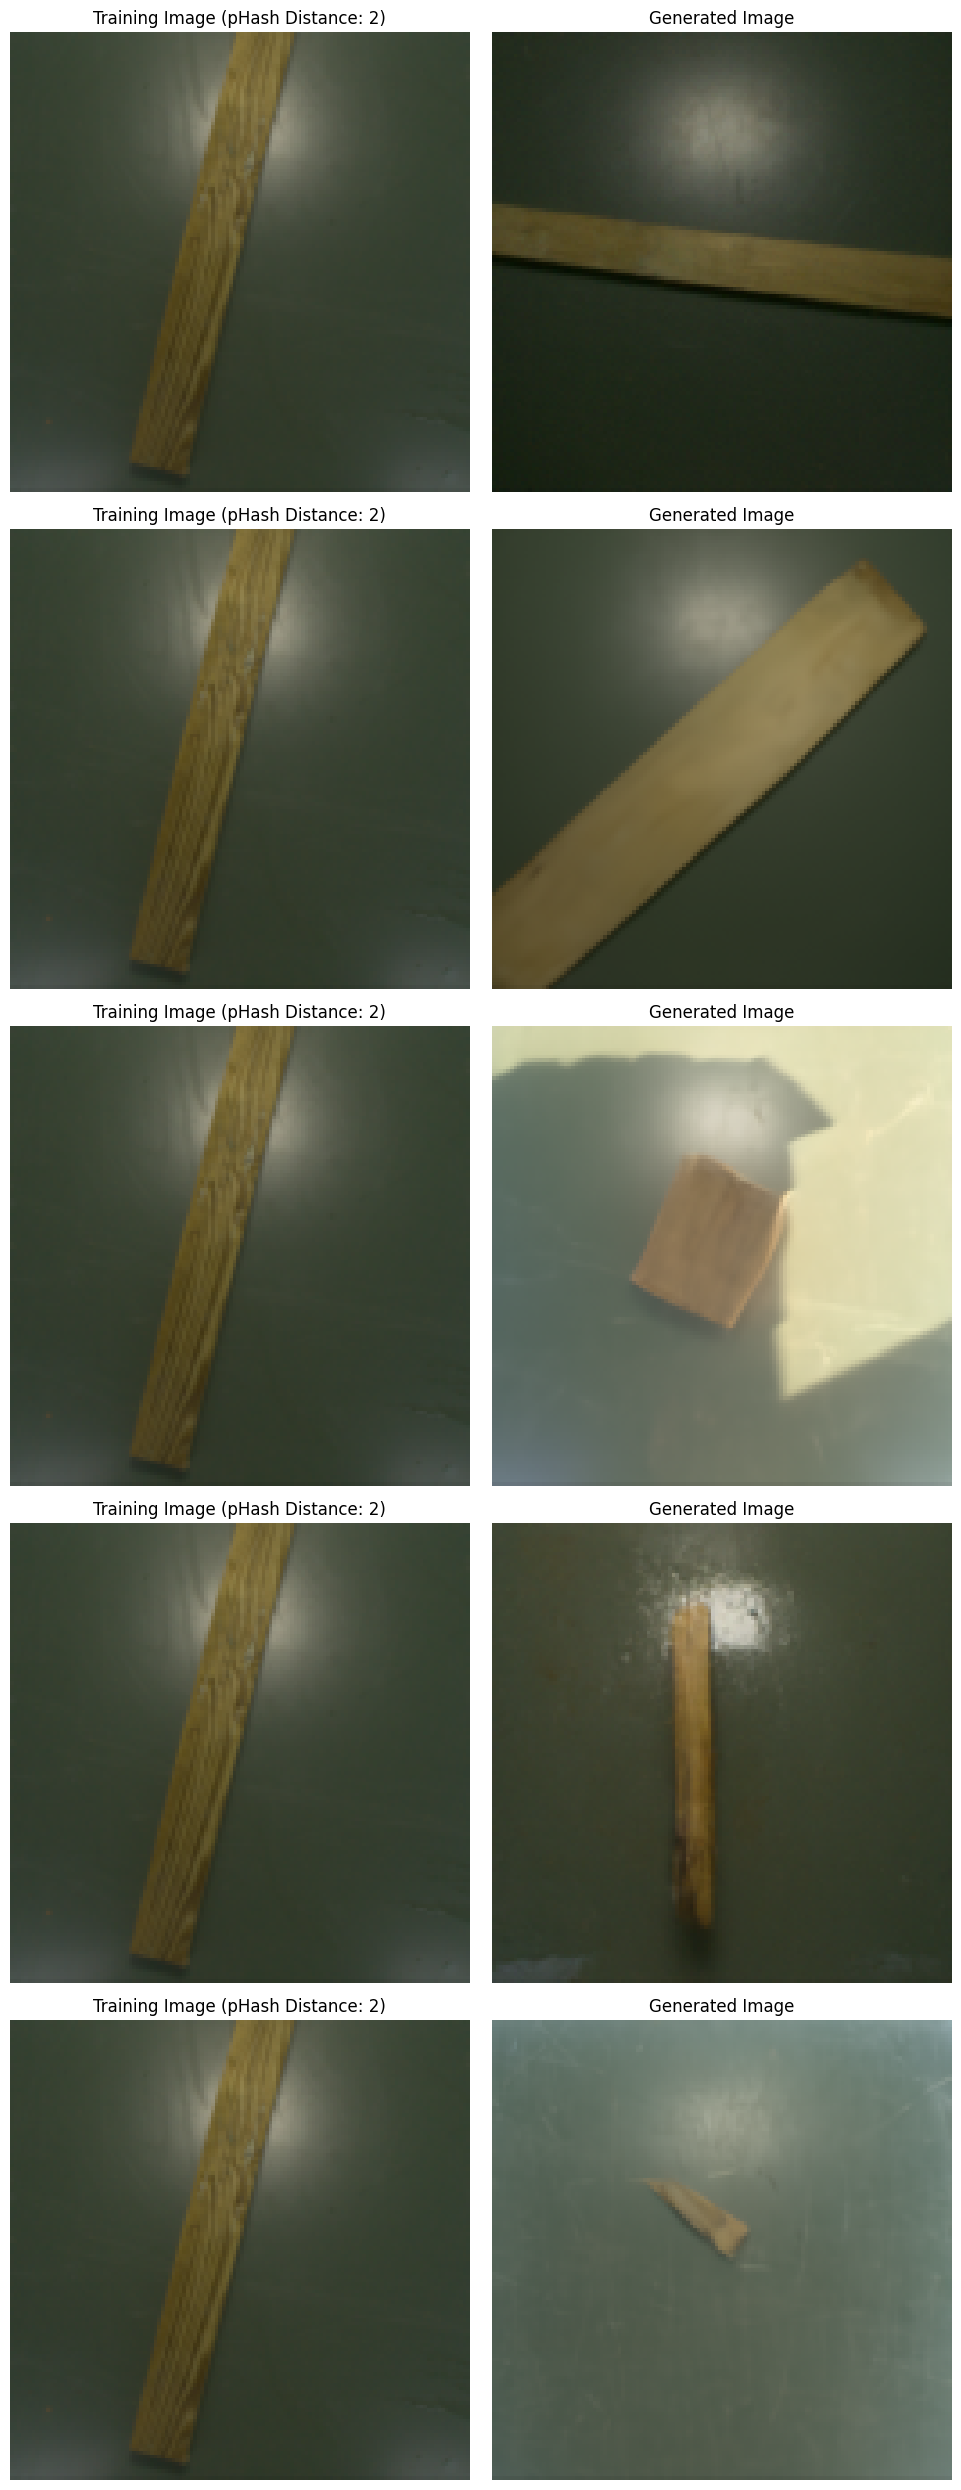

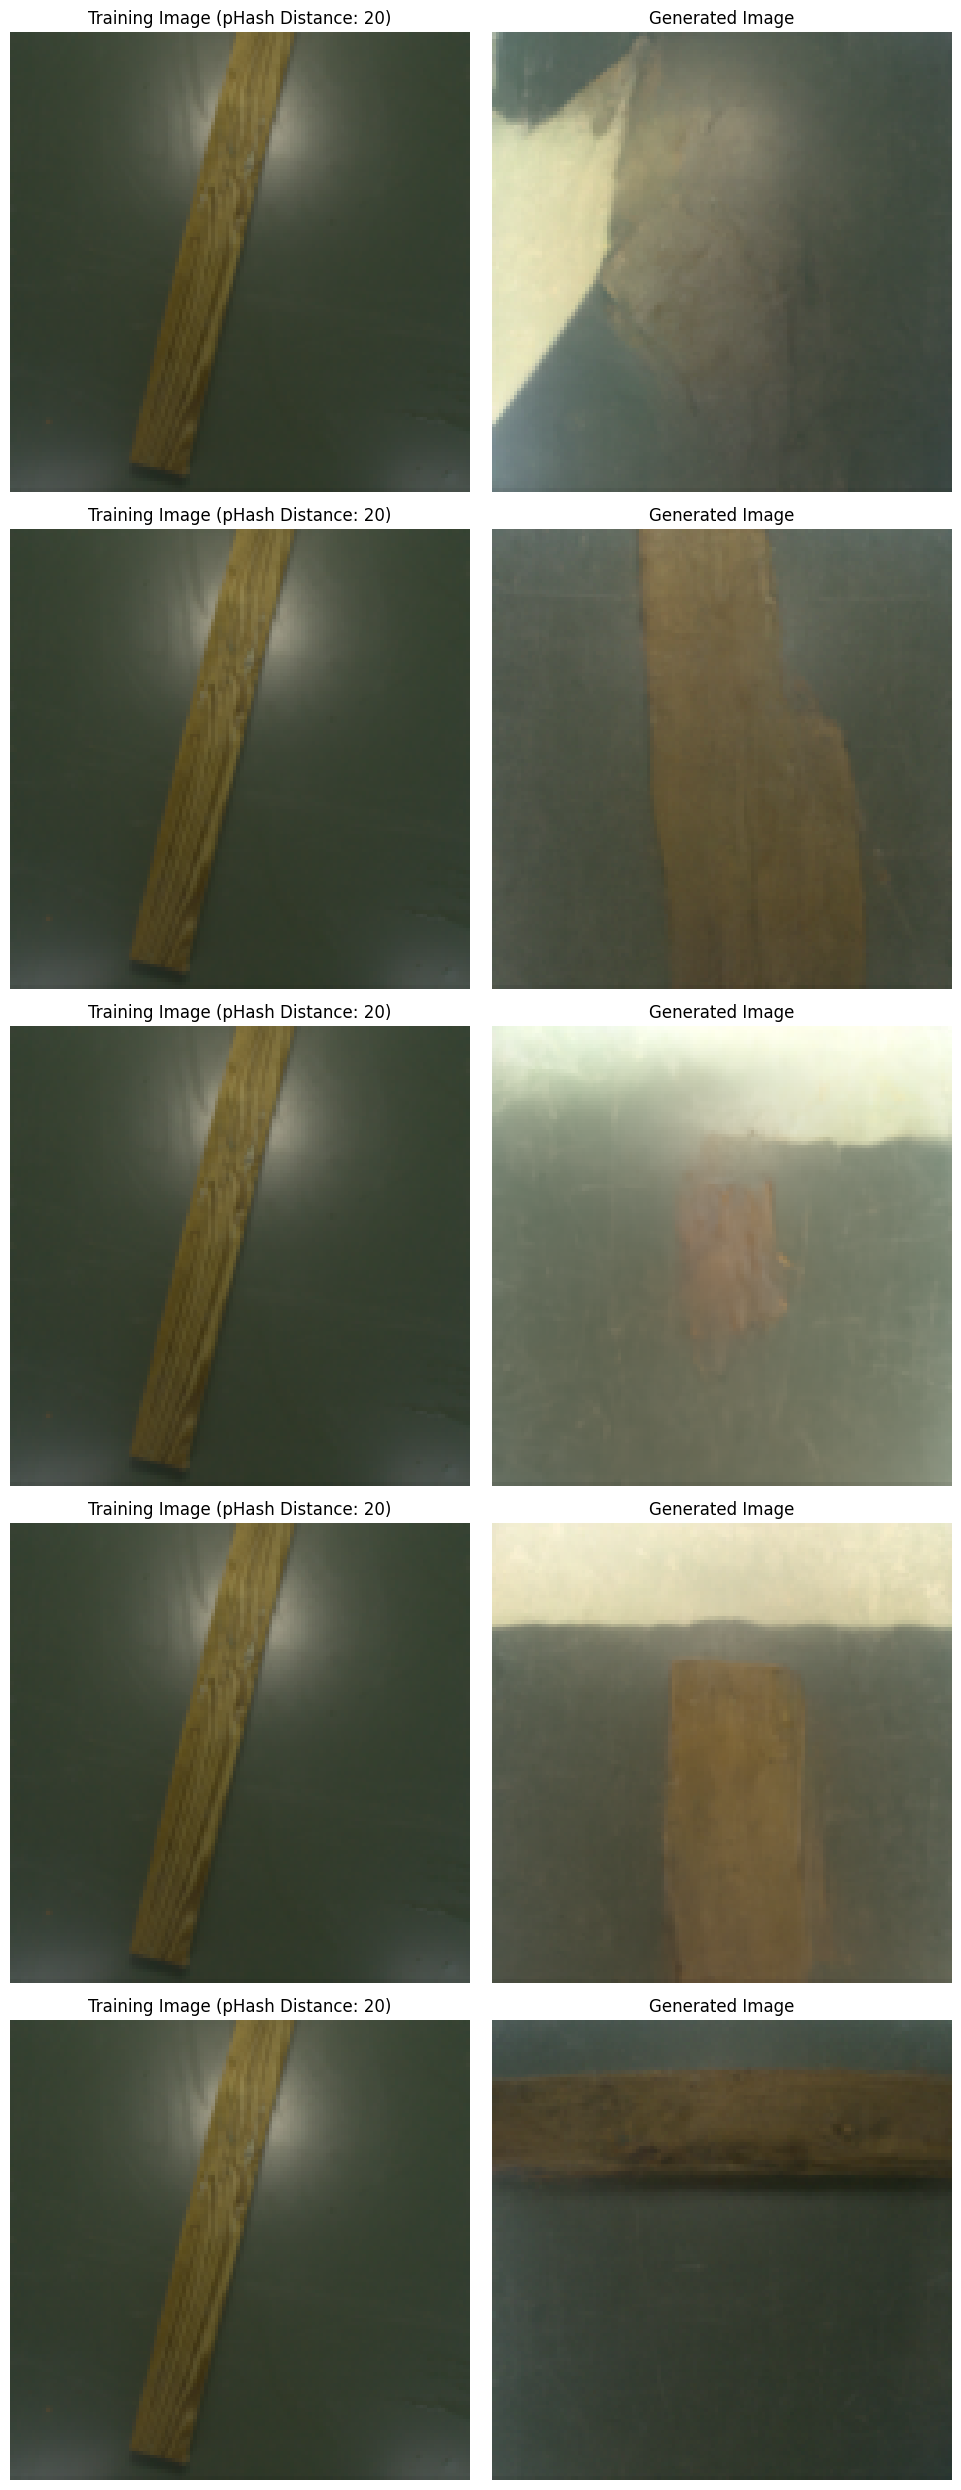

In [31]:
#Display histogram of similarities
import matplotlib.pyplot as plt
plt.hist(similarities, bins=30)
plt.title('Histogram of pHash Similarities')
plt.xlabel('Hamming Distance')
plt.ylabel('Frequency')
plt.show()

# Plot image pairs with lowest pHash distance
def plot_closest_images(similarities, top_k=5):
    
    closest_indices = np.argsort(similarities)[:top_k]
    
    plt.figure(figsize=(10, 5 * top_k))
    for i, idx in enumerate(closest_indices):
        gen_img = gen_images[idx]
        
        # Find the closest training image
        closest_train_idx = np.argmin([similarities[idx] for _ in range(len(train_images))])
        closest_train_img = train_images[closest_train_idx]
        
        # Images are already PIL in RGB format, just convert to numpy
        gen_img = np.array(gen_img)
        closest_train_img = np.array(closest_train_img)
        
        # Normalize to [0, 1] for matplotlib display
        gen_img = gen_img / 255.0
        closest_train_img = closest_train_img / 255.0
        
        # Plot the pair
        plt.subplot(top_k, 2, 2*i + 1)
        plt.imshow(closest_train_img)
        plt.title(f'Training Image (pHash Distance: {similarities[idx]})')
        plt.axis('off')
        
        plt.subplot(top_k, 2, 2*i + 2)
        plt.imshow(gen_img)
        plt.title('Generated Image')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def plot_farthest_images(similarities, top_k=5):
    
    farthest_indices = np.argsort(similarities)[-top_k:]
    
    plt.figure(figsize=(10, 5 * top_k))
    for i, idx in enumerate(farthest_indices):
        gen_img = gen_images[idx]
        
        # Find the closest training image
        closest_train_idx = np.argmin([similarities[idx] for _ in range(len(train_images))])
        closest_train_img = train_images[closest_train_idx]
        
        # Images are already PIL in RGB format, just convert to numpy
        gen_img = np.array(gen_img)
        closest_train_img = np.array(closest_train_img)
        
        # Normalize to [0, 1] for matplotlib display
        gen_img = gen_img / 255.0
        closest_train_img = closest_train_img / 255.0
        
        # Plot the pair
        plt.subplot(top_k, 2, 2*i + 1)
        plt.imshow(closest_train_img)
        plt.title(f'Training Image (pHash Distance: {similarities[idx]})')
        plt.axis('off')
        
        plt.subplot(top_k, 2, 2*i + 2)
        plt.imshow(gen_img)
        plt.title('Generated Image')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
plot_closest_images(similarities)
plot_farthest_images(similarities)

## FID score